In [1]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from datasets import Dataset

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/predictions",
    exist_ok=True
)

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/results",
    exist_ok=True
)

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/models",
    exist_ok=True
)

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/training_history",
    exist_ok=True
)

In [4]:
course_test = pd.read_csv(
    "/content/drive/MyDrive/ABSA_DATASET/course_test.csv"
)

teacher_balanced = pd.read_csv(
    "/content/drive/MyDrive/ABSA_DATASET/teacher_balanced-new.csv"
)

university_balanced = pd.read_csv(
    "/content/drive/MyDrive/ABSA_DATASET/university_balanced-new.csv"
)

In [5]:
train_df = pd.concat(
    [teacher_balanced, university_balanced]
).reset_index(drop=True)

test_df = course_test.reset_index(drop=True)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (8436, 5)
Test: (844, 7)


In [6]:
def format_input(row):

    return (
        "[DOMAIN] " + row["domain"] +
        " [ASPECT] " + row["aspect"] +
        " [TEXT] " + row["review"]
    )

train_df["input_text"] = train_df.apply(
    format_input,
    axis=1
)

test_df["input_text"] = test_df.apply(
    format_input,
    axis=1
)

In [7]:
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

train_df["label"] = train_df["sentiment"].map(label_map)

test_df["label"] = test_df["sentiment"].map(label_map)

In [8]:
# =====================================================
# TRAIN / VALIDATION SPLIT
# =====================================================

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1111,
    stratify=train_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# FIXED SHARED TEST SET
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (7498, 7)
Validation: (938, 7)
Test: (844, 7)


In [9]:
model_name = "answerdotai/ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [10]:
train_dataset = Dataset.from_pandas(
    train_df[["input_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["input_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["input_text", "label"]]
)

In [11]:
def tokenize_function(examples):

    return tokenizer(
        examples["input_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Map:   0%|          | 0/938 [00:00<?, ? examples/s]

Map:   0%|          | 0/844 [00:00<?, ? examples/s]

In [12]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [13]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {

        "accuracy": accuracy_score(
            labels,
            preds
        ),

        "f1_macro": f1_score(
            labels,
            preds,
            average="macro"
        ),

        "f1_weighted": f1_score(
            labels,
            preds,
            average="weighted"
        )
    }

In [14]:
def run_experiment(

    experiment_name,
    learning_rate=2e-5,
    epochs=5,
    use_class_weights=True
):

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3
    )

    if use_class_weights:

        labels = train_df["label"].values

        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(labels),
            y=labels
        )

        class_weights_tensor = torch.tensor(
            class_weights,
            dtype=torch.float
        )

        class WeightedTrainer(Trainer):

            def compute_loss(
                self,
                model,
                inputs,
                return_outputs=False,
                **kwargs
            ):

                labels = inputs.get("labels")

                outputs = model(**inputs)

                logits = outputs.get("logits")

                loss_fct = nn.CrossEntropyLoss(
                    weight=class_weights_tensor.to(model.device)
                )

                loss = loss_fct(logits, labels)

                return (loss, outputs) if return_outputs else loss

        trainer_class = WeightedTrainer

    else:

        trainer_class = Trainer

    training_args = TrainingArguments(

        output_dir=f"./{experiment_name}",

        eval_strategy="epoch",

        save_strategy="no",

        learning_rate=learning_rate,

        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,

        num_train_epochs=epochs,

        weight_decay=0.01,

        logging_steps=100,

        fp16=True,

        report_to="none"
    )

    trainer = trainer_class(

        model=model,

        args=training_args,

        train_dataset=train_dataset,
        eval_dataset=val_dataset,

        compute_metrics=compute_metrics
    )

    trainer.train()

    test_results = trainer.evaluate(
        test_dataset
    )

    print(test_results)

    predictions = trainer.predict(
        test_dataset
    )

    y_pred = np.argmax(
        predictions.predictions,
        axis=1
    )

    y_true = predictions.label_ids


    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    report_dict = classification_report(

        y_true,
        y_pred,

        target_names=[
            "negative",
            "neutral",
            "positive"
        ],

        output_dict=True
    )

    report_df = pd.DataFrame(
        report_dict
    ).transpose()

    report_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_classification_report.csv"
    )

    print(report_df)

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    cm_df = pd.DataFrame(

        cm,

        index=[
            "Actual Negative",
            "Actual Neutral",
            "Actual Positive"
        ],

        columns=[
            "Pred Negative",
            "Pred Neutral",
            "Pred Positive"
        ]
    )

    cm_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_confusion_matrix.csv"
    )

    print(cm_df)

    # =====================================================
    # TRAINING HISTORY
    # =====================================================

    history = trainer.state.log_history

    history_df = pd.DataFrame(history)

    history_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_training_history.csv",

        index=False
    )

    print(history_df.head())



    # =====================================================
    # FINAL PREDICTIONS
    # =====================================================

    label_reverse_map = {

        0: "negative",
        1: "neutral",
        2: "positive"
    }

    final_predictions_df = test_df.copy()

    final_predictions_df["true_label"] = y_true

    final_predictions_df["predicted_label"] = y_pred

    final_predictions_df["true_sentiment"] = (

        final_predictions_df["true_label"]
        .map(label_reverse_map)
    )

    final_predictions_df["predicted_sentiment"] = (

        final_predictions_df["predicted_label"]
        .map(label_reverse_map)
    )

    final_predictions_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/predictions/{experiment_name}_predictions.csv",

        index=False
    )

    print(final_predictions_df.head())

    # ERROR ANALYSIS
    errors_df = final_predictions_df[

        final_predictions_df["true_label"]
        != final_predictions_df["predicted_label"]
    ]

    errors_df.to_csv(
        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_errors.csv",
        index=False
    )

    print("Total Errors:", len(errors_df))

    # NEUTRAL ERROR
    neutral_errors = errors_df[

        errors_df["true_sentiment"]
        == "neutral"
    ]

    neutral_errors.to_csv(
        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_neutral_errors.csv",
        index=False
    )

    print("Neutral Errors:", len(neutral_errors))

    # =====================================================
    # METRICS CSV
    # =====================================================

    metrics_df = pd.DataFrame({

        "Metric": [
            "Accuracy",
            "Macro_F1",
            "Weighted_F1"
        ],

        "Score": [

            test_results["eval_accuracy"],
            test_results["eval_f1_macro"],
            test_results["eval_f1_weighted"]
        ]
    })

    metrics_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_metrics.csv",

        index=False
    )

    print(metrics_df)

    # =====================================================
    # SAVE MODEL
    # =====================================================

    trainer.save_model(

        f"/content/drive/MyDrive/ABSA_DATASET/models/{experiment_name}"
    )

    tokenizer.save_pretrained(

        f"/content/drive/MyDrive/ABSA_DATASET/models/{experiment_name}"
    )

    # =====================================================
    # CLEANUP
    # =====================================================

    trainer.optimizer = None
    trainer.lr_scheduler = None

    del model
    del trainer

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.ipc_collect()

    return test_results

In [15]:
gc.collect()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

In [16]:
best_metrics = run_experiment(
    "university_teacher_to_course_best"
)

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
W0512 00:34:41.600000 17208 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.564563,0.393966,0.884861,0.786293,0.896982
2,0.453677,0.309644,0.905117,0.825234,0.913889
3,0.214982,0.652317,0.927505,0.822748,0.923450
4,0.117192,0.841016,0.932836,0.849173,0.930712
5,0.037839,0.885468,0.931770,0.849737,0.931931


{'eval_loss': 2.5722618103027344, 'eval_accuracy': 0.7772511848341233, 'eval_f1_macro': 0.7078276002384177, 'eval_f1_weighted': 0.7714976640618045, 'eval_runtime': 3.2306, 'eval_samples_per_second': 261.25, 'eval_steps_per_second': 16.405, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.812081  0.831615  0.821732  291.000000
neutral        0.500000  0.413793  0.452830  145.000000
positive       0.830986  0.867647  0.848921  408.000000
accuracy       0.777251  0.777251  0.777251    0.777251
macro avg      0.714355  0.704352  0.707828  844.000000
weighted avg   0.767604  0.777251  0.771498  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            242            23             26
Actual Neutral              39            60             46
Actual Positive             17            37            354
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.927337  10.487158       0.000019  0.21322

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
epoch4_metrics = run_experiment(
    "university_teacher_to_course_4epoch",
    epochs=4
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.593095,0.400186,0.881663,0.780449,0.889071
2,0.418458,0.289482,0.907249,0.828191,0.916587
3,0.266042,0.636741,0.920043,0.826328,0.919086
4,0.097710,0.763841,0.926439,0.841732,0.926390


{'eval_loss': 1.9888670444488525, 'eval_accuracy': 0.7796208530805687, 'eval_f1_macro': 0.7196417952725046, 'eval_f1_weighted': 0.7795354778274327, 'eval_runtime': 3.2065, 'eval_samples_per_second': 263.214, 'eval_steps_per_second': 16.529, 'epoch': 4.0}
              precision    recall  f1-score     support
negative       0.825784  0.814433  0.820069  291.000000
neutral        0.482759  0.482759  0.482759  145.000000
positive       0.851942  0.860294  0.856098  408.000000
accuracy       0.779621  0.779621  0.779621    0.779621
macro avg      0.720161  0.719162  0.719642  844.000000
weighted avg   0.779497  0.779621  0.779535  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            237            31             23
Actual Neutral              37            70             38
Actual Positive             13            44            351
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.944109  12.996347       0.000019  0.2132

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
lr1e5_metrics = run_experiment(
    "university_teacher_to_course_lr1e5",
    learning_rate=1e-5
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.654274,0.444296,0.863539,0.753916,0.877424
2,0.435770,0.417274,0.813433,0.726469,0.850963
3,0.311213,0.535972,0.917910,0.825018,0.918914
4,0.248556,0.652291,0.909382,0.815405,0.914123
5,0.111302,0.774619,0.917910,0.821340,0.920331


{'eval_loss': 2.2319231033325195, 'eval_accuracy': 0.7606635071090048, 'eval_f1_macro': 0.6799439577646091, 'eval_f1_weighted': 0.7508650805625942, 'eval_runtime': 3.197, 'eval_samples_per_second': 263.996, 'eval_steps_per_second': 16.578, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.795302  0.814433  0.804754  291.000000
neutral        0.467290  0.344828  0.396825  145.000000
positive       0.808656  0.870098  0.838253  408.000000
accuracy       0.760664  0.760664  0.760664    0.760664
macro avg      0.690416  0.676453  0.679944  844.000000
weighted avg   0.745405  0.760664  0.750865  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            237            26             28
Actual Neutral              39            50             56
Actual Positive             22            31            355
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.928518  15.025196       0.000010  0.21322

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [20]:
lr3e5_metrics = run_experiment(
    "university_teacher_to_course_lr3e5",
    learning_rate=3e-5
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.550031,0.371098,0.902985,0.818142,0.908847
2,0.456512,0.297664,0.920043,0.843131,0.925025
3,0.263215,0.412357,0.922175,0.846450,0.925565
4,0.129627,0.761295,0.931770,0.860532,0.931982
5,0.039563,0.832038,0.938166,0.869617,0.937810


{'eval_loss': 2.718574047088623, 'eval_accuracy': 0.7950236966824644, 'eval_f1_macro': 0.7252151575929432, 'eval_f1_weighted': 0.7877199510959904, 'eval_runtime': 3.2598, 'eval_samples_per_second': 258.915, 'eval_steps_per_second': 16.259, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.834459  0.848797  0.841567  291.000000
neutral        0.539823  0.420690  0.472868  145.000000
positive       0.834483  0.889706  0.861210  408.000000
accuracy       0.795024  0.795024  0.795024    0.795024
macro avg      0.736255  0.719731  0.725215  844.000000
weighted avg   0.783852  0.795024  0.787720  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            247            23             21
Actual Neutral              33            61             51
Actual Positive             16            29            363
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.944683   6.926890       0.000029  0.21322

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
no_weights_metrics = run_experiment(
    "university_teacher_to_course_no_weights",
    use_class_weights=False
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.312084,0.243797,0.918977,0.786524,0.909542
2,0.222487,0.196377,0.927505,0.832618,0.925020
3,0.127392,0.295450,0.928571,0.846221,0.928780
4,0.053426,0.453987,0.931770,0.862290,0.933918
5,0.021251,0.486644,0.931770,0.867362,0.933927


{'eval_loss': 1.3342714309692383, 'eval_accuracy': 0.7962085308056872, 'eval_f1_macro': 0.7334633370200049, 'eval_f1_weighted': 0.7929321496073266, 'eval_runtime': 3.2446, 'eval_samples_per_second': 260.122, 'eval_steps_per_second': 16.335, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.840989  0.817869  0.829268  291.000000
neutral        0.526718  0.475862  0.500000  145.000000
positive       0.848837  0.894608  0.871122  408.000000
accuracy       0.796209  0.796209  0.796209    0.796209
macro avg      0.738848  0.729446  0.733463  844.000000
weighted avg   0.790791  0.796209  0.792932  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            238            32             21
Actual Neutral              32            69             44
Actual Positive             13            30            365
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.654808   5.768996       0.000019  0.2132

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

             Experiment  Accuracy  Macro_F1  Weighted_F1
0  Weighted Loss (Best)  0.777251  0.707828     0.771498
1              4 Epochs  0.779621  0.719642     0.779535
2             LR = 1e-5  0.760664  0.679944     0.750865
3             LR = 3e-5  0.795024  0.725215     0.787720
4      No Weighted Loss  0.796209  0.733463     0.792932


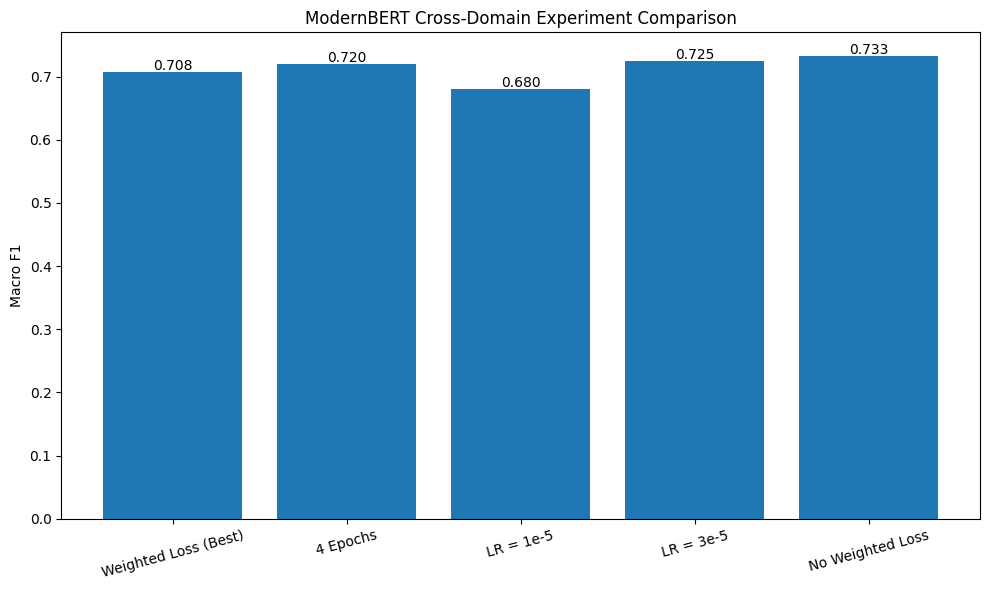

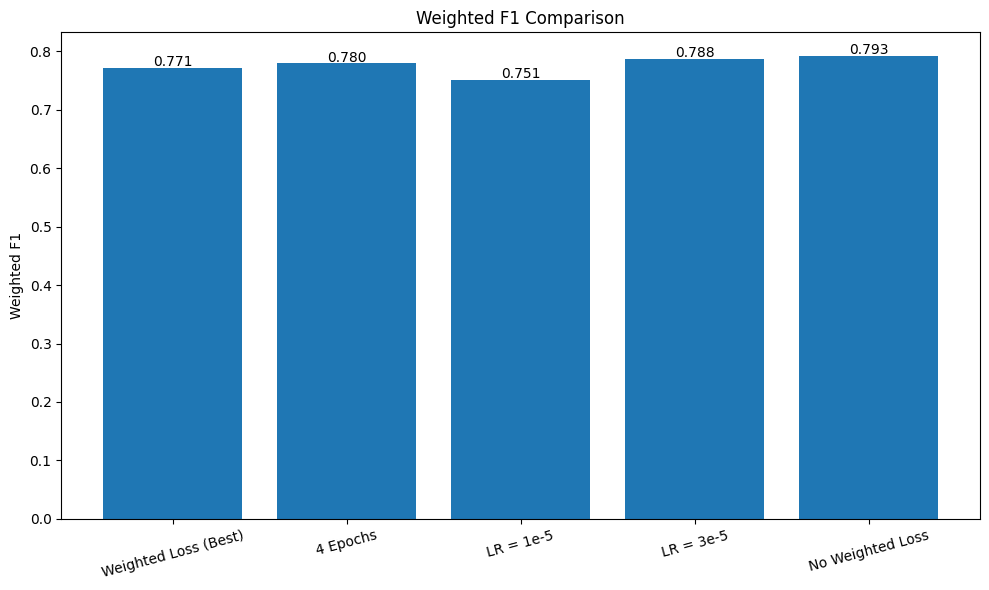

Plots saved successfully


In [22]:
import matplotlib.pyplot as plt

# =====================================================
# FINAL RESULTS TABLE
# =====================================================

final_results_df = pd.DataFrame({

    "Experiment": [

        "Weighted Loss (Best)",
        "4 Epochs",
        "LR = 1e-5",
        "LR = 3e-5",
        "No Weighted Loss"
    ],

    "Accuracy": [

        best_metrics["eval_accuracy"],
        epoch4_metrics["eval_accuracy"],
        lr1e5_metrics["eval_accuracy"],
        lr3e5_metrics["eval_accuracy"],
        no_weights_metrics["eval_accuracy"]
    ],

    "Macro_F1": [

        best_metrics["eval_f1_macro"],
        epoch4_metrics["eval_f1_macro"],
        lr1e5_metrics["eval_f1_macro"],
        lr3e5_metrics["eval_f1_macro"],
        no_weights_metrics["eval_f1_macro"]
    ],

    "Weighted_F1": [

        best_metrics["eval_f1_weighted"],
        epoch4_metrics["eval_f1_weighted"],
        lr1e5_metrics["eval_f1_weighted"],
        lr3e5_metrics["eval_f1_weighted"],
        no_weights_metrics["eval_f1_weighted"]
    ]
})

print(final_results_df)

# =====================================================
# SAVE FINAL RESULTS
# =====================================================

final_results_df.to_csv(

    "/content/drive/MyDrive/ABSA_DATASET/results/course_teacher_to_university_final_results.csv",

    index=False
)

# =====================================================
# MACRO F1 COMPARISON PLOT
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results_df["Experiment"],
    final_results_df["Macro_F1"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.ylabel("Macro F1")

plt.title("ModernBERT Cross-Domain Experiment Comparison")

plt.tight_layout()

plt.savefig(

    "/content/drive/MyDrive/ABSA_DATASET/results/course_teacher_to_university_macrof1.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# WEIGHTED F1 COMPARISON PLOT
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results_df["Experiment"],
    final_results_df["Weighted_F1"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.ylabel("Weighted F1")

plt.title("Weighted F1 Comparison")

plt.tight_layout()

plt.savefig(

    "/content/drive/MyDrive/ABSA_DATASET/results/course_teacher_to_university_weightedf1.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plots saved successfully")

In [18]:
check_df = pd.read_csv(

    "/content/drive/MyDrive/ABSA_DATASET/predictions/university_teacher_to_course_best_predictions.csv"
)

print(check_df.columns)

print(check_df[["row_id", "true_sentiment", "predicted_sentiment"]].head())

Index(['review', 'aspect', 'sentiment', 'domain', 'row_id', 'input_text',
       'label', 'true_label', 'predicted_label', 'true_sentiment',
       'predicted_sentiment'],
      dtype='object')
        row_id true_sentiment predicted_sentiment
0   course_188       negative            negative
1  course_3409       negative            negative
2   course_254       negative            negative
3  course_1797       positive            negative
4  course_3891       positive            positive
